<a href="https://colab.research.google.com/github/AliyaBadmaeva/normflow/blob/Main/Badmaeva_AA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Примечание к работе**

Чтобы запустить ячейки - каждую отдельно, начиная с выделенной, я использовала комбинацию Shift + Enter во время отладки, а затем, когда все было готово (на мой взгляд), я встала на последнюю ячейку (пустую) в данном блокноте и нажала Ctrl + F8, что автоматически запустило все ячейки блокнота.

Картинки подгружаются с Google-Диска (встроены в код), доступ к ним открыт по ссылке, они содержатся в общей папке "Badmaeva A.A. (PZAD)" https://drive.google.com/drive/folders/1XspF31arfRGx8efShLwXmwkvMQifbOZI?usp=drive_link. Рекомендую запускать данный блокнот в Google-Colab, потому что я готовила данный блокнот в Google Colab и при запуске финальной версии блокнота не было ошибок. Этот файл выложен также на моем личном Googlе-диске в той же папке: https://drive.google.com/file/d/1LUMkJY6uVe2SEGD47QJKr6CySPJ66VXJ/view?usp=drive_link, где его удобно и запустить, нажав на кнопку "Запустить в Google Colab".


Предобученные модели для этого блокнота есть на Google-диске, но в коде я прописала более удобную для меня версию - автоматической подгрузки из github.

In [1]:
!pip install --upgrade nbformat
!pip install --upgrade nbconvert

# **Теоретическая часть**

# **Нормализационные потоки (Normalizing Flows) - это вид генеративных моделей в компьютерном зрении.**

Суть потоков заключается в том, что мы обучаем нейронную сеть переводить известное простое распределение (нормальное, равномерное) в распределение нашего набора данных, причем путем последовательного применения нескольких обратимых преобразований.

## **Нормализация потоков**

Пусть сеть задается обратимой функцией $f(x)$, которая принимает на вход изображения. Цель модели в результате обучения научиться переводить входные данные $x$ в элементы $z$ заранее заданного распределения - нормального или равномерного.




Код ниже - это код для встраивания картинки с гугл-диска.

In [2]:
%%html
<iframe src="https://drive.google.com/file/d/1BmUfkNVofGV8EbjbbrNlnq74ICO8dbFY/preview" width="640" height="480" allow="autoplay"></iframe>

Когда сеть обучена, генерация происходит следующим образом: в силу обратимости функции $f$ мы можем подавать на вход в функцию
${f^{-1}}$ элементы $z$ из некоторого распределения (которое мы использовали при обучении модели) и, вычисляя
${f^{-1}}(z)$, получать некоторое изображение.



In [3]:
%%html
<iframe src="https://drive.google.com/file/d/1a0y_S6V8p_pOpamOB8kUVT5qLsaEKGfZ/preview" width="640" height="480" allow="autoplay"></iframe>

## **Математика нормализационных потоков**

Рассмотрим теорию нормализационных потоков.
Задача:
- у нас есть объекты $\ z$ из простого распределения $\ p_z (z)$ - мы его сами задаем (это может быть нормальное или равномерное распределение)
- также у нас есть объекты $\ x$ из нашей выборки - допустим, это фотографии людей, и наша задача - научиться генерировать другие фотографии людей. То есть существует некоторое распределение $\ p_x (x)$, которому принадлежат фотографии, и нам необходимо это распределение выучить - оно нам неизвестно

В нормализационных потоках мы задаем нейронную сеть $\ z = f(x)$, являющуюся непрерывной и обратимой функцией. Каким же образом она поможет нам выучить распределение?



In [4]:
%%html
<iframe src="https://drive.google.com/file/d/14k__wSiyd_FImTEV9tLbgZo9pgpHiHzn/preview" width="640" height="480" allow="autoplay"></iframe>

### **Теорема о замене переменных**

Имея наши вводные, мы можем записать теорему о замене переменных:
$p_x (x_i) = p_z(f(x_i))|det($$\frac{\partial f(x_i)}{\partial x_i}$$)|$,

где $$\frac{\partial f(x_i)}{\partial x_i}$$ - матрица, имеющая вид


In [5]:
%%html
<iframe src="https://drive.google.com/file/d/12HuaMF69pioYNJzr8Ed_zfdjoFo43b8S/preview" width="640" height="480" allow="autoplay"></iframe>

Таким образом, зная некоторое простое распределение, а также имея наши объекты (фотографии) и функцию $f$, мы можем получить неизвестное распределение наших объектов.

#### Пример
Разберем на примере как действует теорема о замене переменных. Пусть функция $f$ имеет вид $z = f(x) = 0.5x - 2.5$ и переводит объекты из некоторого распределения в стандартное нормальное распределение $p(z) ∼ N(0,1)$.

Найдем распределение $p_x(x)$.




In [6]:
%%html
<iframe src="https://drive.google.com/file/d/1qklsvCJ9zS8KC0aAE8e9S0CzJuV8Nmd4/preview" width="640" height="480" allow="autoplay"></iframe>

Применим теорему о замене переменной:

$z = f(x) = 0.5x - 2.5$, поэтому $\ $$\frac{\partial f(x)}{\partial x}$$ = 0.5$ и, значит, $|det $$\frac{\partial f(x)}{\partial x}$$| = 0.5$  

Плотность стандартного нормального распределения: $p_z(z) = \frac {1}{\sqrt {2 \pi}} e^{\frac {-z^2}{2}} $


Подставляем все это в формулу замены переменных:


$p_z(z) = \frac {1}{\sqrt {2 \pi}} e^{\frac {-(0.5x - 2.5)^2}{2}} 0.5 =  \frac {1}{2 \sqrt {2 \pi}} e^{\frac {-(x - 5)^2}{8}} = N(5, 2)$



In [7]:
%%html
<iframe src="https://drive.google.com/file/d/1CtQIvU06sGpthvI629ARdaezpQ_fJOLW/preview" width="640" height="480" allow="autoplay"></iframe>

### **Обратная замена**
Формула замены переменных в данной задаче:
$p_x (x_i) = p_z(f(x_i))|det($$\frac{\partial f(x_i)}{\partial x_i}$$)|$

Обратная замена будет происходить по формуле:

$p_z (z_i) = p_x(f^{-1}(z_i))|det($$\frac{\partial f^{-1}(z_i)}{\partial z_i}$$)|$


### **Формализация задачи обучения нормализационного потока**

Теперь можно формализовать главную задачу.
1. При обучении мы будем находить веса нейронной сети $f$, задающей преобразование $z_i = f(x_i)$

Веса будем находить методом градиентного спуска.

2. При обучении минимизируем некоторую функцию потерь.

Здесь мы оперируем вероятностными распределениями, поэтому функция потерь - это минус логарифм правдоподобия:

$L = - \frac {1}{n} \sum_{i=1}^{n} \log p_x (x_i)$

Перепишем функцию потерь через известные нам величины:

Знаем, что $p_x (x_i) = p_z(f(x_i))|det($$\frac{\partial f(x_i)}{\partial x_i}$$)|$,

поэтому

$L = - \frac {1}{n} \sum_{i=1}^{n} (\log p_z(f(x_i)) + \log|\frac{\partial f(x_i)}{\partial x_i}|)$

## **Этапы обучения нормализационных потоков**

**1. Обучение**

В цикле:

- Берем $m$ реальных объектов $\{x_1, ..., x_m\}$;

- Вычисляем значение функции потерь:

$L = - \frac {1}{n} \sum_{i=1}^{n} (\log p_z(f(x_i)) + \log|det \frac{\partial f(x_i)}{\partial x_i}|)$

- Обновляем веса $w$ в функции (или нейронной сети) $z = f(x) = f(w, x)$:

$w := w - \triangledown_w L(w)$

**2. Применение (генерация объектов)**

- Сэмплируем объекты из случайного шума $\{z_1, ..., z_m\}$;
- Генерируем новые объекты $\{x_1, ..., x_m\}$ по формуле:

$x_i = f^{-1} (z_i)$




In [8]:
%%html
<iframe src="https://drive.google.com/file/d/1hoXkaprlfA19zqDUsBwZ14_0A73tyLMV/preview" width="640" height="480" allow="autoplay"></iframe>

### **Пример нормализационного потока: Real-NVP**

В качестве функции $f(x)$ в нормализационном потоке подойдет не любое преобразование и не любая нейронная сеть. Нам нужно, чтобы функция $f$ была дифференцируема и обратима.

Одним из классических примеров нормализационных потоков является Real-NVP. В нем преобразование $f$ задается по формуле:


In [9]:
%%html
<iframe src="https://drive.google.com/file/d/1N6FsC81bHDJKsdPVYcS5JKZTPE6DiI41/preview" width="640" height="480" allow="autoplay"></iframe>


То есть первые $d$ координат не меняются, а координаты с номерами $d + 1, ..., D$ вычисляются по формуле, указанной выше.

Здесь $s$ и $t$ - нейронные сети с $d$ входами и $D − d$ выходами.

Ниже приведена схема преобразования $f$ для случая двух координат:


In [10]:
%%html
<iframe src="https://drive.google.com/file/d/1rI_HsaNCQ-X8LxTzfwROPgyX0TTKiV1q/preview" width="640" height="480" allow="autoplay"></iframe>


Преобразование $f$ нам подходит, так как оно дифференцируемо и обратимо.

Необходимые для вычисления функции потерь компоненты выглядят так:

- Матрица первых производных:


In [11]:
%%html
<iframe src="https://drive.google.com/file/d/12Dn_q8Z4saizhi9bKbeElTdmiDlDdEph/preview" width="640" height="480" allow="autoplay"></iframe>


- Определитель Якобиана:


In [12]:
%%html
<iframe src="https://drive.google.com/file/d/1I0wARiq7lxEQmzEF42LFm7KuUUW9WnvZ/preview" width="640" height="480" allow="autoplay"></iframe>

Обратное преобразование имеет вид:


In [13]:
%%html

<iframe src="https://drive.google.com/file/d/1Wb5zSsfoxeuMe4fqjmAQfWF42TzOHFt1/preview" width="640" height="480" allow="autoplay"></iframe>

Преобразование довольно простое, поэтому и качество генерации получается не самым лучшим, но все равно довольно неплохим. На картинке ниже приведен пример генерации лиц людей при помощи Real-NVP.

In [14]:
%%html
<iframe src="https://drive.google.com/file/d/130gd5rxyYOvYMycOTZZpti8aM27Wd341/preview" width="640" height="480" allow="autoplay"></iframe>

# **Нормализационные потоки на практике**


Практически невозможно подобрать одно такое обратимое преобразование $f$, которое будет с хорошим качеством переводить объекты нашего распределения в нормальное (равномерное) распределение, поэтому на практике используют последовательность таких преобразований:


In [15]:
%%html

<iframe src="https://drive.google.com/file/d/1erjYam-e8U1xHl52Vmi4hvWrDEB69aB7/preview" width="640" height="480" allow="autoplay"></iframe>

В итоге имеется последовательность (поток) преобразований, переводящих наши данные в нормальное (как правило) распределение - отсюда и название, нормализационный поток.

Генерация при помощи нормализационных потоков получается качественной, но с некоторыми особенностями (это видно на границах контуров объектов):



In [16]:
%%html

<iframe src="https://drive.google.com/file/d/1PfWNJS0TyqrILOSJj7piPy7uQMNYkgks/preview" width="640" height="480" allow="autoplay"></iframe>

# **Практическая часть работы**

Примечание:
Нормализация потоков обычно является параметрически тяжелой и, следовательно, вычислительно дорогой. В данном случае будут использоваться относительно простые потоки, чтобы сэкономить вычислительные затраты.

In [17]:
# импорт стандартных библиотек
import os
import math
import time
import numpy as np

# импорт библиотек для построения графиков
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf') # для экспорта
from matplotlib.colors import to_rgb
import matplotlib
matplotlib.rcParams['lines.linewidth'] = 2.0
import seaborn as sns
sns.reset_orig()

# Progress bar
from tqdm.notebook import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
# Torchvision
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms
# PyTorch Lightning
try:
    import pytorch_lightning as pl
except ModuleNotFoundError: # Google Colab не имеет PyTorch Lightning, установленного по умолчанию. Поэтому мы делаем это здесь, если необходимо
    !pip install --quiet pytorch-lightning>=1.4
    import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint

/tmp/ipython-input-17-2044822282.py:11: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg', 'pdf') # для экспорта


In [18]:
os.system("taskset -c -p 0-7 %d" % os.getpid())  # чтобы далее не было предупреждений о возможности использования максимум 2 рабочих процессов, когда нам надо 8

0

In [19]:
# Путь к папке, в которую загружены наборы данных. Это стандартные наборы данных, которые загружены в Google-Colab по умолчанию и есть всегда при запуске, их не надо грузить отдельно
dataset_path = "/content/sample_data/"
# Путь к папке, в которой сохранены предварительно обученные модели
checkpoint_path = "/content/pretrained_models/"

# Настройки семечка
pl.seed_everything(42)

INFO:lightning_fabric.utilities.seed:Seed set to 42


42

In [20]:
# Чтобы убедиться, что все операции на графическом процессоре (если используется) являются детерминированными для воспроизводимости.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Выбор устройства, которое будет использоваться в этом блокноте
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Используя устройство", device)

Используя устройство cpu


In [21]:
import urllib.request
from urllib.error import HTTPError

#URL-адрес Github, где хранятся сохраненные модели в формате raw для этого блокнота
# т.к. если написать прямую ссылку на гитхаб, то будет закачан не raw-файл, что нам не подходит.
base_url = "https://raw.githubusercontent.com/AliyaBadmaeva/normflow/Main/pretrained_models/"

# Файлы для загрузки запишем в список
pretrained_files = ["MNISTFlow_simple.ckpt", "MNISTFlow_vardeq.ckpt", "MNISTFlow_multiscale.ckpt"]

# Создаем путь контрольной точки, если он еще не существует
os.makedirs(checkpoint_path, exist_ok=True)

# Для каждого файла проверьте, существует ли он
for file_name in pretrained_files:
    file_path = os.path.join(checkpoint_path, file_name)
    if not os.path.isfile(file_path):
        file_url = base_url + file_name
        print(f"Загрузка {file_url}...")
        try:
            urllib.request.urlretrieve(file_url, file_path)
        except HTTPError as e:
            print("Что-то пошло не так. Попробуйте загрузить файл из папки GDrive или свяжитесь с автором, предоставив полный вывод, включая следующую ошибку:\n", e)

Загрузка https://raw.githubusercontent.com/AliyaBadmaeva/normflow/Main/pretrained_models/MNISTFlow_simple.ckpt...
Загрузка https://raw.githubusercontent.com/AliyaBadmaeva/normflow/Main/pretrained_models/MNISTFlow_vardeq.ckpt...
Загрузка https://raw.githubusercontent.com/AliyaBadmaeva/normflow/Main/pretrained_models/MNISTFlow_multiscale.ckpt...


In [22]:
!ls /content/pretrained_models/  # посмотреть список содержимого папки

MNISTFlow_multiscale.ckpt  MNISTFlow_simple.ckpt  MNISTFlow_vardeq.ckpt


В этом блокноте мы будем использовать набор данных MNIST. Несмотря на свою простоту этот набор представляет собой сложную задачу для небольших генеративных моделей, поскольку требует глобального понимания изображения. В то же время можно легко оценить, происходят ли сгенерированные изображения из того же распределения, что и набор данных (т. е. представляют ли они реальные цифры), или нет.

Чтобы лучше управляться с дискретной природой изображений, мы преобразуем их из диапазона 0-1 в диапазон 0-255 в качестве целых чисел.

In [23]:
# Преобразование изображений от 0-1 до 0-255 (целые числа)
def discret(sample):
    return (sample * 255).to(torch.int32)

# Преобразования, применяемые к каждому изображению => превращаем их в тензор и дискретизируем
transform = transforms.Compose([transforms.ToTensor(), discret])

# Загрузка обучающего (тренировочного) набора данных. Нам нужно разделить его на обучающую и валидационную выборки.
train_dataset = MNIST(root=dataset_path, train=True, transform=transform, download=True)
pl.seed_everything(42)
train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])  # разделили

# Загрузка тестового набора данных
test_set = MNIST(root=dataset_path, train=False, transform=transform, download=True)

# Мы определяем набор загрузчиков данных, которые впоследствии сможем использовать для различных целей.
# Для фактического обучения модели мы будем использовать разные загрузчики данных с меньшим размером выборки.
train_loader = data.DataLoader(train_set, batch_size=256, shuffle=False, drop_last=False)  # тренировочный
val_loader = data.DataLoader(val_set, batch_size=64, shuffle=False, drop_last=False, num_workers=4)  # валидационный
test_loader = data.DataLoader(test_set, batch_size=64, shuffle=False, drop_last=False, num_workers=4)  # тестовый

100%|██████████| 9.91M/9.91M [00:00<00:00, 129MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 11.0MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 46.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.35MB/s]
INFO:lightning_fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Кроме того, ниже мы определим функцию для упрощения визуализации изображений/образцов. Некоторые обучающие примеры набора данных MNIST показаны ниже.

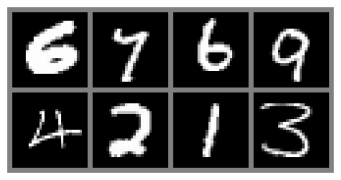

In [24]:
def show_imgs(imgs, title=None, row_size=4):
    # сетка картинок (максимально 8 колонок)
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    is_int = imgs.dtype==torch.int32 if isinstance(imgs, torch.Tensor) else imgs[0].dtype==torch.int32
    nrow = min(num_imgs, row_size)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128 if is_int else 0.5)
    np_imgs = imgs.cpu().numpy()
    # Plot the grid
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    if title is not None:
        plt.title(title)
    plt.show()
    plt.close()

show_imgs([train_set[i][0] for i in range(8)])

## **Наша задача с набором данных MNIST**

В качестве общей концепции мы построим нормализующий поток, который сопоставляет входное изображение (в данном случае MNIST) со скрытым пространством такого же размера:


In [25]:
%%html
<iframe src="https://drive.google.com/file/d/1eRpeR9ctWetsERSol_TzAuBpTtDJUlAH/preview" width="640" height="480" allow="autoplay"></iframe>

В качестве первого шага мы реализуем шаблон нормализующего потока в PyTorch Lightning. Во время обучения и проверки нормализующий поток выполняет оценку плотности в прямом направлении. Для этого мы применяем ряд преобразований потока к входным данным x и оцениваем вероятность входных данных, определяя вероятность преобразованной точки z, заданной априорно, и изменение объема, вызванное преобразованиями. Во время вывода мы можем выполнять как оценку плотности, так и выборку новых точек, инвертируя преобразования потока. Поэтому мы определяем функцию `_get_likelihood`, которая выполняет оценку плотности, и выборку `sample` для генерации новых примеров. Функции `training_step`, `validation_step` и `test_step` используют `_get_likelihood`.
Стандартная метрика, используемая в генеративных моделях и, в частности, в нормализации потоков, — это биты на измерения (bpd). Bpd мотивируется с точки зрения теории информации и описывает, сколько бит нам понадобится для кодирования конкретного примера в нашем смоделированном распределении. Чем меньше бит нам нужно, тем вероятнее пример в нашем распределении. Когда мы проверяем биты на измерение нашего тестового набора данных, мы можем судить, обобщается ли наша модель на новые образцы набора данных и не запомнила ли она обучающий набор данных. Чтобы вычислить оценку бит на измерение, мы можем положиться на отрицательное логарифмическое правдоподобие и изменить базу логарифма (поскольку биты являются двоичными, а NLL обычно является экспоненциальным):

$$\text{bpd} = \text{nll} \cdot \log_2\left(\exp(1)\right) \cdot \left(\prod d_i\right)^{-1}$$

где $d_1,...,d_K$ — размеры входных данных. Для изображений это высота, ширина и номер канала. Мы делим логарифм правдоподобия на эти дополнительные измерения, чтобы получить метрику, которую мы можем сравнивать для разных разрешений изображений. В исходном пространстве изображений примеры MNIST имеют оценку бит на измерение 8 (нам нужно 8 бит для кодирования каждого пикселя, так как существует 256 возможных значений).

In [26]:
class ImageFlow(pl.LightningModule):  # создаем класс потока изображений

    def __init__(self, flows, import_samples=8):  # конструктор или функция инициализации
        """
        Входные данные:
            flows (потоки) - Список потоков (каждый из которых — nn.Module), которые следует применить к изображениям.
            import_samples - Количество важных образцов для использования во время тестирования (см. пояснение ниже).
            Может быть изменено в любое время
        """
        super().__init__()
        self.flows = nn.ModuleList(flows)
        self.import_samples = import_samples
        # Создаем предварительное распределение для конечного скрытого пространства
        self.prior = torch.distributions.normal.Normal(loc=0.0, scale=1.0)
        # Пример ввода для визуализации графика
        self.example_input_array = train_set[0][0].unsqueeze(dim=0)

    def forward(self, imgs):
        # Функция forward используется только для визуализации графика.
        return self._get_likelihood(imgs)

    def encode(self, imgs):
        # Для заданного набора изображений вернуть скрытое представление z и ldj преобразований
        z, ldj = imgs, torch.zeros(imgs.shape[0], device=self.device)
        for flow in self.flows:
            z, ldj = flow(z, ldj, reverse=False)
        return z, ldj

    def _get_likelihood(self, imgs, return_ll=False):
        """
        Учитывая партию изображений, вернуть их вероятность.
        Если return_ll имеет значение True, эта функция возвращает логарифмическую вероятность входных данных.
        В противном случае выходная метрика — это биты на измерение (масштабированная отрицательная логарифмическая вероятность)
        """
        z, ldj = self.encode(imgs)
        log_pz = self.prior.log_prob(z).sum(dim=[1,2,3])
        log_px = ldj + log_pz
        nll = -log_px
        # Расчет бит на измерение
        bpd = nll * np.log2(np.exp(1)) / np.prod(imgs.shape[1:])
        return bpd.mean() if not return_ll else log_px

    @torch.no_grad()
    def sample(self, img_shape, z_init=None):
        """
        Выбор партии изображений из потока.
        """
        # Образец скрытого представления из предыдущего
        if z_init is None:
            z = self.prior.sample(sample_shape=img_shape).to(device)
        else:
            z = z_init.to(device)

        # Преобразуем z в x, инвертируя потоки
        ldj = torch.zeros(img_shape[0], device=device)
        for flow in reversed(self.flows):
            z, ldj = flow(z, ldj, reverse=True)
        return z

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=1e-3)
        # Планировщик необязателен, но может помочь в потоках для получения последнего улучшения bpd
        scheduler = optim.lr_scheduler.StepLR(optimizer, 1, gamma=0.99)
        return [optimizer], [scheduler]

    def training_step(self, batch, batch_idx):
        # Нормализационные потоки обучаются по принципу максимального правдоподобия => return bpd
        loss = self._get_likelihood(batch[0])
        self.log('train_bpd', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self._get_likelihood(batch[0])
        self.log('val_bpd', loss)

    def test_step(self, batch, batch_idx):
        # Провести выборку по важности во время тестирования => оценить вероятность M раз для каждого изображения
        samples = []
        for _ in range(self.import_samples):
            img_ll = self._get_likelihood(batch[0], return_ll=True)
            samples.append(img_ll)
        img_ll = torch.stack(samples, dim=-1)

        # Чтобы усреднить вероятности, нам нужно перейти от логарифмического пространства к экспоненциальному и обратно к логарифмическому..
        # Logsumexp предоставляет нам стабильную реализацию для этого
        img_ll = torch.logsumexp(img_ll, dim=-1) - np.log(self.import_samples)

        # Рассчет окончательного bpd
        bpd = -img_ll * np.log2(np.exp(1)) / np.prod(batch[0].shape[1:])
        bpd = bpd.mean()

        self.log('test_bpd', bpd)

Функция `test_step` отличается от шага обучения и проверки тем, что она использует выборку по важности. Мы обсудим мотивацию и детали, стоящие за этим, после того, как разберемся, как потоки моделируют дискретные изображения в непрерывном пространстве.

## **Деквантование**
Нормализация потоков основана на правиле изменения переменных, которое естественным образом определено в непрерывном пространстве. Применение потоков непосредственно к дискретным данным приводит к нежелательным моделям плотности, где произвольно высокая вероятность помещается на несколько конкретных значений. Пример ниже:


In [27]:
%%html
<iframe src="https://drive.google.com/file/d/1_3mGud745Os0UZA6q1oshp0voTmnGbk4/preview" width="640" height="480" allow="autoplay"></iframe>




Черные точки представляют собой дискретные точки, а зеленый объем — плотность, смоделированную нормализующим потоком в непрерывном пространстве. Поток будет продолжать увеличивать вероятность для $x=0,1,2,3$, не имея объема в любой другой точке. Помните, что в непрерывном пространстве у нас есть ограничение, что общий объем плотности вероятности должен быть равен 1 ($\int p(x)dx=1$). В противном случае мы больше не моделируем распределение вероятности. Однако дискретные точки $x=0,1,2,3$ представляют собой дельта-пики без ширины в непрерывном пространстве. Вот почему поток может придавать этим нескольким точкам бесконечно высокую вероятность, при этом все еще представляя распределение в непрерывном пространстве. Тем не менее, изученная плотность ничего не говорит нам о распределении среди дискретных точек, так как в дискретном пространстве вероятности этих четырех точек должны были бы в сумме давать 1, а не бесконечность.

Чтобы предотвратить такие вырожденные решения, общим решением является добавление небольшого количества шума к каждому дискретному значению, что также называется деквантованием. Рассматривая $x$ как целое число (как это имеет место для изображений), деквантованное представление $v$ можно сформулировать как $v=x+u$, где $u\in[0,1)^D$. Таким образом, дискретное значение 1 моделируется распределением по интервалу  $[1.0,2.0)$, значение 2 по объему $[2.0,3.0)$, и т.д. Нашей целью моделирования $p(x)$ становится:

$$ p(x) = \int p(x+u)du = \int \frac{q(u|x)}{q(u|x)}p(x+u)du = \mathbb{E}_{u\sim q(u|x)}\left[\frac{p(x+u)}{q(u|x)} \right]$$

где $q(u|x)$ — распределение шума. На данный момент мы предполагаем, что оно равномерное, что также можно записать как $p(x)=\mathbb{E}_{u\sim U(0,1)^D}\left[p(x+u) \right]$.

Далее мы реализуем деквантизацию как само преобразование потока. После добавления шума к дискретным значениям мы дополнительно преобразуем объем в форму, подобную гауссовской. Это делается путем масштабирования $x+u$ между 0 и 1 и применения инвертирования сигмоидальной функции $\sigma(z)^{-1} = \log z - \log 1-z$. Если бы мы этого не сделали, то столкнулись бы с двумя проблемами:

Входные данные масштабируются между 0 и 256, в то время как априорное распределение является гауссовым со средним значением 0 и стандартным отклонением 1. На первых итерациях после инициализации параметров потока у нас были бы крайне низкие вероятности для больших значений, таких как 256. Это привело бы к мгновенному расхождению обучения.
Поскольку выходное распределение является гауссовым, потоку выгодно иметь входное распределение аналогичной формы. Это снизит сложность моделирования, требуемую потоком.
В целом мы можем реализовать деквантование следующим образом:

In [28]:
class Dequantization(nn.Module):  # Класс деквантования

    def __init__(self, alpha=1e-5, quants=256):  # функция инициализации
        """
        Входные данные:
            alpha — малая константа, используемая для масштабирования исходного входного сигнала.
            Предотвращает работу со значениями, очень близкими к 0 и 1, при инвертировании сигмоиды
            quants - Количество возможных дискретных значений (обычно 256 для 8-битного изображения)
        """
        super().__init__()
        self.alpha = alpha
        self.quants = quants

    def forward(self, z, ldj, reverse=False):
        if not reverse:
            z, ldj = self.dequant(z, ldj)
            z, ldj = self.sigmoid(z, ldj, reverse=True)
        else:
            z, ldj = self.sigmoid(z, ldj, reverse=False)
            z = z * self.quants
            ldj += np.log(self.quants) * np.prod(z.shape[1:])
            z = torch.floor(z).clamp(min=0, max=self.quants-1).to(torch.int32)
        return z, ldj

    def sigmoid(self, z, ldj, reverse=False):
        # Применяет обратимое сигмоидальное преобразование
        if not reverse:
            ldj += (-z-2*F.softplus(-z)).sum(dim=[1,2,3])
            z = torch.sigmoid(z)
            # Обратное масштабирование для численной стабильности
            ldj -= np.log(1 - self.alpha) * np.prod(z.shape[1:])
            z = (z - 0.5 * self.alpha) / (1 - self.alpha)
        else:
            z = z * (1 - self.alpha) + 0.5 * self.alpha  # Такое масштабирование, чтобы не было границ 0 и 1
            ldj += np.log(1 - self.alpha) * np.prod(z.shape[1:])
            ldj += (-torch.log(z) - torch.log(1-z)).sum(dim=[1,2,3])
            z = torch.log(z) - torch.log(1-z)
        return z, ldj

    def dequant(self, z, ldj):
        # Преобразование дискретных значений в непрерывные объемы
        z = z.to(torch.float32)
        z = z + torch.rand_like(z).detach()
        z = z / self.quants
        ldj -= np.log(self.quants) * np.prod(z.shape[1:])
        return z, ldj

Хорошая проверка того, правильно ли реализован поток, — это проверка его обратимости. Поэтому мы деквантуем случайно выбранное обучающее изображение, а затем квантуем его снова. Мы ожидаем, что получим точно такое же изображение:

In [29]:
# Тестирование обратимости слоя деквантования
pl.seed_everything(42)
orig_img = train_set[0][0].unsqueeze(dim=0)
ldj = torch.zeros(1,)
dequant_module = Dequantization()  # создаем объект класса
deq_img, ldj = dequant_module(orig_img, ldj, reverse=False)
reconst_img, ldj = dequant_module(deq_img, ldj, reverse=True)

d1, d2 = torch.where(orig_img.squeeze() != reconst_img.squeeze())
if len(d1) != 0:
    print("Деквантование не было обратимым.")
    for i in range(d1.shape[0]):
        print("Первоначальная стоимость:", orig_img[0,0,d1[i], d2[i]].item())
        print("Восстановленная стоимость::", reconst_img[0,0,d1[i], d2[i]].item())
else:
    print("Успешно инвертированное деквантование")

# Слой не является строго обратимым из-за ограничений точности float
# assert (orig_img == reconst_img).all().item()

INFO:lightning_fabric.utilities.seed:Seed set to 42


Успешно инвертированное деквантование


Тест проходит успешно, как и ожидалось. Однако есть вероятность, что тест не пройдет из-за числовых неточностей в инвертированной сигмоиде. В то время как входное пространство для инвертированной сигмоиды масштабируется между 0 и 1, выходное пространство находится между $−\infty$ и $\infty$. И поскольку мы используем 32 бита для представления чисел (в дополнение к многократному применению логарифмов), такие неточности могут возникать и не должны вызывать беспокойства. Тем не менее, хорошо знать о них, и их можно улучшить, используя двойной тензор (float64).

Наконец, мы можем взять нашу деквантизацию и фактически визуализировать распределение, в которое она преобразует дискретные значения:

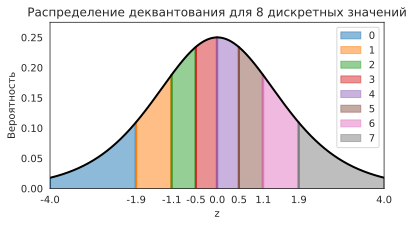

In [30]:
def visualize_dequantization(quants, prior=None):
    """
    Функция визуализации значений деквантования дискретных величин в непрерывном пространстве
    """
    # Предшествующие дискретным значениям. Если не указано, предполагается равномерное
    if prior is None:
        prior = np.ones(quants, dtype=np.float32) / quants
    prior = prior / prior.sum()  # Обеспечиваем правильное категориальное распределение

    inp = torch.arange(-4, 4, 0.01).view(-1, 1, 1, 1) # Возможные непрерывные значения, которые мы хотим рассмотреть
    ldj = torch.zeros(inp.shape[0])
    dequant_module = Dequantization(quants=quants)
    # Инвертировать деквантование непрерывных значений, чтобы найти соответствующее дискретное значение
    out, ldj = dequant_module.forward(inp, ldj, reverse=True)
    inp, out, prob = inp.squeeze().numpy(), out.squeeze().numpy(), ldj.exp().numpy()
    prob = prob * prior[out] # Вероятность, масштабированная по категориальным априорным значениям

    # Объемы участков и непрерывное распределение
    sns.set_style("white")
    fig = plt.figure(figsize=(6,3))
    x_ticks = []
    for v in np.unique(out):
        indices = np.where(out==v)
        color = to_rgb(f"C{v}")
        plt.fill_between(inp[indices], prob[indices], np.zeros(indices[0].shape[0]), color=color+(0.5,), label=str(v))
        plt.plot([inp[indices[0][0]]]*2,  [0, prob[indices[0][0]]],  color=color)
        plt.plot([inp[indices[0][-1]]]*2, [0, prob[indices[0][-1]]], color=color)
        x_ticks.append(inp[indices[0][0]])
    x_ticks.append(inp.max())
    plt.xticks(x_ticks, [f"{x:.1f}" for x in x_ticks])
    plt.plot(inp,prob, color=(0.0,0.0,0.0))
    # Установим окончательные свойства графика
    plt.ylim(0, prob.max()*1.1)
    plt.xlim(inp.min(), inp.max())
    plt.xlabel("z")  # надпись по оси x
    plt.ylabel("Вероятность")  # надпись по оси y
    plt.title(f"Распределение деквантования для {quants} дискретных значений")
    plt.legend()
    plt.show()  # показать график
    plt.close()

visualize_dequantization(quants=8)

Визуализированное распределение показывает подобъемы, которые назначены различным дискретным значениям. Значение 0 имеет свой объем между $[− \infty,−1.9)$ , значение 1 представлено интервалом $[−1.9,−1.1)$, и т. д. Объем для каждого дискретного значения имеет одинаковую массу вероятности. Вот почему объемы, близкие к центру (например, 3 и 4), имеют меньшую площадь на оси $z$, чем другие ($z$ используется для обозначения выхода всего потока деквантования).

Фактически, последовательный нормализующий поток моделирует дискретные изображения, преследуя следующую цель:

$$\log p(x) = \log \mathbb{E}_{u\sim q(u|x)}\left[\frac{p(x+u)}{q(u|x)} \right] \geq \mathbb{E}_{u}\left[\log \frac{p(x+u)}{q(u|x)} \right]$$

Хотя нормализующие потоки точны по правдоподобию, у нас есть нижняя граница. В частности, это пример неравенства Йенсена, поскольку нам нужно переместить логарифм в ожидание, чтобы мы могли использовать оценки Монте-Карло. В целом, эта граница значительно меньше, чем ELBO в вариационных автоэнкодерах. На самом деле, мы можем сами уменьшить границу, оценив ожидание не на одну, а на M выборок. Другими словами, мы можем применить выборку важности, что приводит к следующему неравенству:

$$\log p(x) = \log \mathbb{E}_{u\sim q(u|x)}\left[\frac{p(x+u)}{q(u|x)} \right] \geq \mathbb{E}_{u}\left[\log \frac{1}{M} \sum_{m=1}^{M} \frac{p(x+u_m)}{q(u_m|x)} \right] \geq \mathbb{E}_{u}\left[\log \frac{p(x+u)}{q(u|x)} \right]$$

Выборка по значимости $\frac {1}{M} \sum_{m=1}^M \frac{p(x+u_m)}{q(u_m|x)}$ становится $\mathbb{E}_{u∼q(u|x)}[\frac{p(x+u)}{q(u|x)}$ если $M \to \infty$, так что чем больше образцов мы используем, тем теснее граница. Во время тестирования мы можем использовать это свойство и реализовать его в `test_step` в `ImageFlow`. Теоретически мы также могли бы использовать эту более тесную границу во время обучения. Однако связанная работа показала, что это не обязательно приводит к улучшению, учитывая дополнительные вычислительные затраты, и более эффективно придерживаться одной оценки.

### **Вариационное деквантование**
Деквантование использует равномерное распределение для шума $\ u$, что фактически приводит к тому, что изображения представляются в виде гиперкубов (кубов в больших измерениях) с резкими границами. Однако моделирование таких резких границ нелегко для потока, поскольку он использует плавные преобразования для преобразования его в гауссово распределение.

Другой способ взглянуть на это — изменить предыдущее распределение в предыдущей визуализации. Представьте, что у нас есть независимый гауссов шум на пикселях, что обычно имеет место для любой реальной фотографии. Поэтому поток должен будет моделировать распределение, как указано выше, но с отдельными объемами, масштабированными следующим образом:

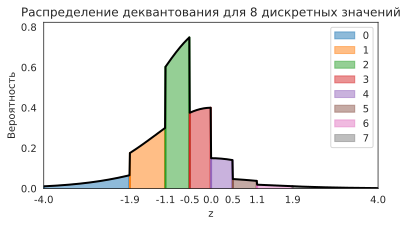

In [31]:
# Вызываем функцюя визуализации значений деквантования дискретных величин, созданнуюранее

visualize_dequantization(quants=8, prior=np.array([0.075, 0.2, 0.4, 0.2, 0.075, 0.025, 0.0125, 0.0125]))

Преобразование такой вероятности в гауссово распределение является сложной задачей, особенно с такими жесткими границами. Поэтому деквантование было распространено на более сложные, обучаемые распределения за пределами равномерного в вариационной структуре. В частности, если мы помним цель обучения $\log p(x) = \log \mathbb{E}_{u}\left[\frac{p(x+u)}{q(u|x)} \right]$, равномерное распределение можно заменить обученным распределением $q_{\theta}(u|x)$ с поддержкой на $u\in[0,1)^D$. Этот подход называется вариационным деквантованием, он был предложен Хо и др.. Как мы можем обучить такое распределение? Мы можем использовать второй нормализующий поток, который принимает $x$ в качестве внешнего входа и обучается гибкому распределению на $u$. Чтобы обеспечить поддержку на $[0,1)^D$, мы можем применить сигмоидальную функцию активации в качестве конечного преобразования потока.

Наследуя исходный класс деквантования, мы можем реализовать вариационное деквантование следующим образом:

In [32]:
class VariationalDequantization(Dequantization):  # класс вариационного деквантования

    def __init__(self, var_flows, alpha=1e-5):
        """
        Входные данные:
            var_flows -Список преобразований потоков, которые можно использовать для моделирования q(u|x)
            alpha - Малая константа, была описана см. в разделе Деквантование
        """
        super().__init__(alpha=alpha)
        self.flows = nn.ModuleList(var_flows)

    def dequant(self, z, ldj):
        z = z.to(torch.float32)
        img = (z / 255.0) * 2 - 1 # Мы обуславливаем потоки по x, т.е. исходному изображению

        # Априорное распределение u, как и прежде, является равномерным.
        # Поскольку большинство преобразований потока определены на [-бесконечность,+бесконечность], сначала применим обратную сигмоиду.
        deq_noise = torch.rand_like(z).detach()
        deq_noise, ldj = self.sigmoid(deq_noise, ldj, reverse=True)
        for flow in self.flows:
            deq_noise, ldj = flow(deq_noise, ldj, reverse=False, orig_img=img)
        deq_noise, ldj = self.sigmoid(deq_noise, ldj, reverse=False)

        # После потоков, применяем u как при стандартном деквантовании
        z = (z + deq_noise) / 256.0
        ldj -= np.log(256.0) * np.prod(z.shape[1:])
        return z, ldj  # возвращаемые значения

Вариационное деквантование может быть использовано в качестве замены деквантованию. Сравнение деквантования и вариационное деквантования будет представлено далее.

### **Связывающие слои**

Далее рассмотрим возможные преобразования, которые можно применить внутри потока. Недавно популярный слой потока, который хорошо работает в сочетании с глубокими нейронными сетями, — это слой связи, введенный Динем и др. Входное значение $z$ произвольно делится на две части, $z_{1:j}$ и $z_{j+1:d}$, из которых первая остается неизменной потоком. Тем не менее, $z_{1:j}$ используется для параметризации преобразования для второй части $z_{j+1:d}$. Далее мы остановимся на самом простом и эффективном: аффинном связывании. В этом слое связи мы применяем аффинное преобразование, сдвигая вход на смещение $\mu$ и масштабируя его на $\sigma$. Другими словами, наше преобразование выглядит следующим образом:

$$z'_{j+1:d} = \mu_{\theta}(z_{1:j}) + \sigma_{\theta}(z_{1:j}) \odot z_{j+1:d}$$

Функции $\mu$ и $\sigma$ реализованы как общая нейронная сеть, а сумма и умножение выполняются поэлементно. Таким образом, LDJ является суммой логарифмов масштабирующих факторов: $\sum_i \left[\log \sigma_{\theta}(z_{1:j})\right]_i$. Инвертирование слоя может быть выполнено просто вычитанием смещения и делением на масштаб:

$$z_{j+1:d} = \left(z'_{j+1:d} - \mu_{\theta}(z_{1:j})\right) / \sigma_{\theta}(z_{1:j})$$

Мы также можем визуализировать слой связи в виде вычислительного графика, где $z_1$ представляет $z_{1:j}$, а $z_2$ представляет $z_{j+1:d}$:


In [33]:
%%html
<iframe src="https://drive.google.com/file/d/1cCtjN6XAkV6n5YZQXMxbb_QiU1N_X0mf/preview" width="640" height="480" allow="autoplay"></iframe>


В нашей реализации мы реализуем разделение переменных как маскирование. Переменные, которые должны быть преобразованы, $z_{j+1:d}$, маскируются при передаче $z$ в общую сеть для прогнозирования параметров преобразования. При применении преобразования мы маскируем параметры для $z_{1:j}$, чтобы у нас была операция тождества для этих переменных:

In [34]:
class CouplingLayer(nn.Module):  # класс для связывающего слоя

    def __init__(self, network, mask, c_in):
        """
        Связывающий слой внутри нормализующего потока.
        Входные каналы:
            network - Модуль PyTorch nn.Module, составляющий глубокую нейронную сеть для mu и sigma.
                      Форма выходного сигнала должна быть в два раза больше размера канала входного сигнала.
            mask - Двоичная маска (0 или 1), где 0 означает, что элемент должен быть преобразован, а 1 означает,
            что скрытый элемент будет использоваться в качестве входных данных для нейронной сети.
            c_in - Количество входных каналов
        """
        super().__init__()
        self.network = network
        self.scaling_factor = nn.Parameter(torch.zeros(c_in))
        # Регистрация маски как буфера, поскольку это тензор, который не является параметром,
        # но должен быть частью состояния модуля.
        self.register_buffer('mask', mask)

    def forward(self, z, ldj, reverse=False, orig_img=None):
        """
        Входные данные:
            z - Скрытый вход в поток
            ldj - Текущий ldj предыдущих потоков.
                  К этому тензору будет добавлен ldj этого слоя.
            reverse - Если True, мы применяем инверсию слоя.
            orig_img (опционально) - Требуется только в VarDeq.
            Позволяет внешнему вводу обуславливать поток (например, исходное изображение)
        """
        # Применить сеть к замаскированному входному каналу
        z_in = z * self.mask
        if orig_img is None:
            nn_out = self.network(z_in)
        else:
            nn_out = self.network(torch.cat([z_in, orig_img], dim=1))
        s, t = nn_out.chunk(2, dim=1)

        # Стабилизация масштабирования выходных данных
        s_fac = self.scaling_factor.exp().view(1, -1, 1, 1)
        s = torch.tanh(s / s_fac) * s_fac

        # Маскирование выходов (преобразование только второй части)
        s = s * (1 - self.mask)
        t = t * (1 - self.mask)

        # Аффинное преобразование
        if not reverse:
            # Независимо от того, сначала ли мы смещаемся, а затем масштабируемся, или наоборот,
            # это выбор дизайна, и обычно он не имеет большого значения.
            z = (z + t) * torch.exp(s)
            ldj += s.sum(dim=[1,2,3])
        else:
            z = (z * torch.exp(-s)) - t
            ldj -= s.sum(dim=[1,2,3])

        return z, ldj

В целях стабилизации мы применяем функцию активации $\tanh$ к масштабируемому выходу. Это предотвращает внезапные большие значения выходных данных для масштабирования, которые могут дестабилизировать обучение. Чтобы по-прежнему допускать коэффициенты масштабирования, меньшие или большие, чем -1 и 1 соответственно, у нас есть обучаемый параметр для каждого измерения, называемый `scaling_factor`. Он масштабирует tanh до различных пределов. Ниже мы визуализируем влияние коэффициента масштабирования на выходную активацию членов масштабирования:

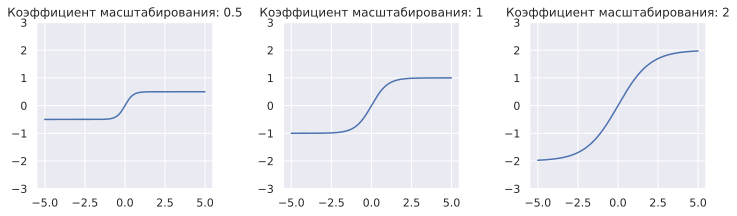

In [35]:
with torch.no_grad():
    x = torch.arange(-5,5,0.01)
    scaling_factors = [0.5, 1, 2]
    sns.set()
    fig, ax = plt.subplots(1, 3, figsize=(12,3))
    for i, scale in enumerate(scaling_factors):
        y = torch.tanh(x / scale) * scale
        ax[i].plot(x.numpy(), y.numpy())
        ax[i].set_title("Коэффициент масштабирования: " + str(scale))
        ax[i].set_ylim(-3, 3)
    plt.subplots_adjust(wspace=0.4)
    sns.reset_orig()
    plt.show()

Связыващие слои обобщаются для любой техники маскирования, которую мы можем себе представить. Однако наиболее распространенный подход для изображений — разделить входной $z$ пополам, используя маску шахматной доски или маску канала. Маска шахматной доски разделяет переменные по высоте и ширине и назначает каждому пикселю $z_{j+1:d}$. Таким образом, маска является общей для всех каналов. Напротив, маска канала назначает половине каналов $z_{j+1:d}$, а другой половине —  $z_{1:j+1}$. Обратите внимание, что когда мы применяем несколько связующих слоев, мы инвертируем маскирование для каждого другого слоя, так что каждая переменная преобразуется одинаковое количество раз.

Реализация функций, которые создают маску шахматной доски и маску канала:

In [36]:
def create_checkerboard_mask(h, w, invert=False):  # функция для создания маски шахматной доски
    x, y = torch.arange(h, dtype=torch.int32), torch.arange(w, dtype=torch.int32)
    xx, yy = torch.meshgrid(x, y, indexing='ij')
    mask = torch.fmod(xx + yy, 2)
    mask = mask.to(torch.float32).view(1, 1, h, w)
    if invert:
        mask = 1 - mask
    return mask

def create_channel_mask(c_in, invert=False):  # функция для создания маски канала
    mask = torch.cat([torch.ones(c_in//2, dtype=torch.float32),
                      torch.zeros(c_in-c_in//2, dtype=torch.float32)])
    mask = mask.view(1, c_in, 1, 1)
    if invert:
        mask = 1 - mask
    return mask

Мы также можем визуализировать соответствующие маски для изображения размером $8\times 8\times 2$ (2 channels):

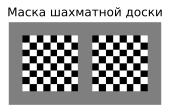

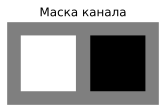

In [37]:
checkerboard_mask = create_checkerboard_mask(h=8, w=8).expand(-1,2,-1,-1) # вызываем функцию создания маски шахматной доски с необходимыми параметрами и записываем в переменную
channel_mask = create_channel_mask(c_in=2).expand(-1,-1,8,8)  # вызываем функцию создания маски канала с необходимыми параметрами и записываем в переменную

show_imgs(checkerboard_mask.transpose(0,1), "Маска шахматной доски")  # отображение маски шахматной доски
show_imgs(channel_mask.transpose(0,1), "Маска канала")  # отображение маски канала

В качестве последнего аспекта связывающих слоев нам нужно решить, какую глубокую нейронную сеть мы хотим применить в связывающих слоях. Входом для слоев является изображение, и поэтому мы придерживаемся CNN (сверточных нейронных сетей). Поскольку вход для преобразования зависит от всех предыдущих преобразований, крайне важно обеспечить хороший градиентный поток через CNN обратно к входу, что может быть оптимально достигнуто с помощью архитектуры, подобной ResNet (глубокая нейронная сеть, разработанная для решения проблемы затухания градиента). В частности, мы будем использовать Gated ResNet, которая добавляет $\sigma$-ворота к пропускному соединению, аналогично входным воротам в LSTM (сети с долговременной и кратковременной памятью). Детали здесь не обязательно важны, и сеть во многом вдохновлена Flow++, если есть заинтересованность в построении еще более сильных моделей.

In [38]:
class ConcatELU(nn.Module):
    """
    Функция активации, которая применяет ELU (функция активации) в обоих направлениях (инвертированном и прямом).
    Обеспечивает нелинейность, обеспечивая при этом сильные градиенты для любого входного сигнала (важно для окончательной свертки)
    """

    def forward(self, x):
        return torch.cat([F.elu(x), F.elu(-x)], dim=1)


class LayerNormChannels(nn.Module):

    def __init__(self, c_in, eps=1e-5):
        """
        Этот модуль применяет норму слоя ко всем каналам изображения.
        Входные данные:
            c_in - Количество каналов входа
            eps - Малая константа для стабилизации стандарта
        """
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(1, c_in, 1, 1))
        self.beta = nn.Parameter(torch.zeros(1, c_in, 1, 1))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(dim=1, keepdim=True)
        var = x.var(dim=1, unbiased=False, keepdim=True)
        y = (x - mean) / torch.sqrt(var + self.eps)
        y = y * self.gamma + self.beta
        return y


class GatedConv(nn.Module):

    def __init__(self, c_in, c_hidden):
        """
        В этом модуле применяется двухслойный сверточный блок ResNet с входными воротами.
        Входные каналы:
            c_in - Количество каналов входа
            c_hidden - Количество скрытых измерений, которые мы хотим смоделировать (обычно похоже на c_in)
        """
        super().__init__()
        self.net = nn.Sequential(
            ConcatELU(),
            nn.Conv2d(2*c_in, c_hidden, kernel_size=3, padding=1),
            ConcatELU(),
            nn.Conv2d(2*c_hidden, 2*c_in, kernel_size=1)
        )

    def forward(self, x):
        out = self.net(x)
        val, gate = out.chunk(2, dim=1)
        return x + val * torch.sigmoid(gate)


class GatedConvNet(nn.Module):

    def __init__(self, c_in, c_hidden=32, c_out=-1, num_layers=3):
        """
        Модуль, который суммирует предыдущие блоки в полную сверточную нейронную сеть.
        Входные данные:
            c_in - Количество каналов входа
            c_hidden - Количество скрытых измерений для использования в сети
            c_out - Количество выходных каналов. Если -1, то используются 2 входных канала (аффинная связь)
            num_layers - Количество применяемых закрытых блоков ResNet
        """
        super().__init__()
        c_out = c_out if c_out > 0 else 2 * c_in
        layers = []
        layers += [nn.Conv2d(c_in, c_hidden, kernel_size=3, padding=1)]
        for layer_index in range(num_layers):
            layers += [GatedConv(c_hidden, c_hidden),
                       LayerNormChannels(c_hidden)]
        layers += [ConcatELU(),
                   nn.Conv2d(2*c_hidden, c_out, kernel_size=3, padding=1)]
        self.nn = nn.Sequential(*layers)

        self.nn[-1].weight.data.zero_()
        self.nn[-1].bias.data.zero_()

    def forward(self, x):
        return self.nn(x)

### **Тренировочный (обучающий) цикл**

Наконец, мы можем добавить слои деквантования, вариационного деквантования и связующие слои, чтобы построить наш полный нормализационный поток на изображениях MNIST. Мы применяем 8 связующих слоев в основном потоке и 4 для вариационного деквантования, если оно применяется. Мы применяем маску шахматной доски по всей сети, как и в случае с одним каналом (черно-белые изображения), мы не можем применить маску канала. Общая архитектура визуализирована ниже.



In [39]:
%%html
<iframe src="https://drive.google.com/file/d/1q97jXHSvZuQN9fm6n3fQn3J2NKSZ6Qz-/preview" width="640" height="480" allow="autoplay"></iframe>

In [40]:
def create_simple_flow(use_vardeq=True):
    flow_layers = []
    if use_vardeq:
        vardeq_layers = [CouplingLayer(network=GatedConvNet(c_in=2, c_out=2, c_hidden=16),
                                       mask=create_checkerboard_mask(h=28, w=28, invert=(i%2==1)),
                                       c_in=1) for i in range(4)]
        flow_layers += [VariationalDequantization(var_flows=vardeq_layers)]
    else:
        flow_layers += [Dequantization()]

    for i in range(8):
        flow_layers += [CouplingLayer(network=GatedConvNet(c_in=1, c_hidden=32),
                                      mask=create_checkerboard_mask(h=28, w=28, invert=(i%2==1)),
                                      c_in=1)]

    flow_model = ImageFlow(flow_layers).to(device)
    return flow_model

Для реализации цикла обучения мы используем фреймворк PyTorch Lightning и сокращаем накладные расходы кода. Снова напоминание о том, что используются предварительно обученные модели, поскольку нормализация потоков особенно затратна для обучения. Таккже проведена проверка и тестирование, поскольку это также может занять некоторое время с дополнительной выборкой важности.

In [41]:
def train_flow(flow, model_name="MNISTFlow"):
    # Создание PyTorch Lightning trainer
    trainer = pl.Trainer(default_root_dir=os.path.join(checkpoint_path, model_name),
                         accelerator="gpu" if str(device).startswith("cuda") else "cpu",
                         devices=1,
                         max_epochs=200,
                         gradient_clip_val=1.0,
                         callbacks=[ModelCheckpoint(save_weights_only=True, mode="min", monitor="val_bpd"),
                                    LearningRateMonitor("epoch")],
                         check_val_every_n_epoch=5)
    trainer.logger._log_graph = True
    trainer.logger._default_hp_metric = None # Опциональный (Необязательный) аргумент регистрации, который нам не нужен

    train_data_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=8)
    result = None

    # Проверка, существует ли предобученная модель. Если да, загрузим ее и пропустим обучение
    pretrained_filename = os.path.join(checkpoint_path, model_name + ".ckpt")
    print(pretrained_filename)
    if os.path.isfile(pretrained_filename):
        print("Найдена предварительно обученная модель, загрузка...")
        ckpt = torch.load(pretrained_filename, map_location=device)
        flow.load_state_dict(ckpt['state_dict'])
        result = ckpt.get("result", None)
    else:
        print("Начало обучения", model_name)
        trainer.fit(flow, train_data_loader, val_loader)

    # Тестирование лучшей модели на валидационной выборке и тестовом наборе, если результат не найден
    # Тестирование может быть дорогостоящим из-за важности выборки.
    if result is None:
        val_result = trainer.test(flow, val_loader, verbose=False)
        start_time = time.time()
        test_result = trainer.test(flow, test_loader, verbose=False)
        duration = time.time() - start_time
        result = {"test": test_result, "val": val_result, "time": duration / len(test_loader) / flow.import_samples}

    return flow, result

## **Многослойная архитектура**

Одним из недостатков нормализационных потоков является то, что они работают с теми же измерениями, что и входные данные. Если входные данные имеют большую размерность, то и скрытое пространство имеет большую размерность, что требует больших вычислительных затрат для изучения подходящих преобразований. Однако, особенно в области изображений, многие пиксели содержат меньше информации в том смысле, что мы могли бы удалить их, не теряя семантическую информацию изображения.

На основе этой интуиции глубокие нормализационные потоки на изображениях обычно применяют многослойную архитектуру. После первых $N$ преобразований потока мы разделяем половину скрытых измерений и напрямую оцениваем их на априорном слое. Другая половина проходит через еще $N$ преобразований потока, и в зависимости от размера входных данных мы снова разделяем его пополам или останавливаемся в этой позиции. Две операции, задействованные в этой настройке, — это `Squeeze` и `Split`, которые мы рассмотрим более подробно и реализуем ниже.

### **Сжатие и разделение**

Когда мы хотим удалить половину пикселей в изображении, у нас возникает проблема выбора переменных для вырезания и способа перегруппировки изображения. Таким образом, операция сжатия обычно используется перед разделением, которая делит изображение на подквадраты формы $2\times 2\times C$ и переформировывает их в блоки $1\times 1\times 4C$. Фактически, мы уменьшаем высоту и ширину изображения в 2 раза, масштабируя количество каналов в 4 раза. После этого мы можем выполнить операцию разделения по каналам без необходимости перегруппировки пикселей. Меньший масштаб также делает общую архитектуру более эффективной. Визуально операция сжатия должна преобразовать входные данные следующим образом:


In [42]:
%%html
<iframe src="https://drive.google.com/file/d/1_H8sx8mqnVoSV_biHy-sUd1Mz3ka68kK/preview" width="640" height="480" allow="autoplay"></iframe>





Вход $4\times 4\times 1$ масштабируется до $2\times 2\times 4$, следуя идее группировки пикселей в $2\times 2\times 1$ подквадраты. Далее попробуем реализовать этот слой:

In [43]:
class SqueezeFlow(nn.Module):

    def forward(self, z, ldj, reverse=False):
        B, C, H, W = z.shape
        if not reverse:
            # Прямое направление: H x W x C => H/2 x W/2 x 4C
            z = z.reshape(B, C, H//2, 2, W//2, 2)
            z = z.permute(0, 1, 3, 5, 2, 4)
            z = z.reshape(B, 4*C, H//2, W//2)
        else:
            # Обратное направление: H/2 x W/2 x 4C => H x W x C
            z = z.reshape(B, C//4, 2, 2, H, W)
            z = z.permute(0, 1, 4, 2, 5, 3)
            z = z.reshape(B, C//4, H*2, W*2)
        return z, ldj

Прежде чем двигаться дальше, мы можем проверить нашу реализацию, сравнив наш вывод с примером на рисунке выше:

In [44]:
sq_flow = SqueezeFlow()
rand_img = torch.arange(1,17).view(1, 1, 4, 4)
print("Изображение (до)\n", rand_img)
forward_img, _ = sq_flow(rand_img, ldj=None, reverse=False)
print("\nИзображение (прямое-forward)\n", forward_img.permute(0,2,3,1)) # ереставляем для удобства чтения
reconst_img, _ = sq_flow(forward_img, ldj=None, reverse=True)
print("\nИзображение (обратное-reverse)\n", reconst_img)

Изображение (до)
 tensor([[[[ 1,  2,  3,  4],
          [ 5,  6,  7,  8],
          [ 9, 10, 11, 12],
          [13, 14, 15, 16]]]])

Изображение (прямое-forward)
 tensor([[[[ 1,  2,  5,  6],
          [ 3,  4,  7,  8]],

         [[ 9, 10, 13, 14],
          [11, 12, 15, 16]]]])

Изображение (обратное-reverse)
 tensor([[[[ 1,  2,  3,  4],
          [ 5,  6,  7,  8],
          [ 9, 10, 11, 12],
          [13, 14, 15, 16]]]])


Операция split делит входные данные на две части и оценивает одну часть непосредственно на основе априорной вероятности. Чтобы наша операция потока соответствовала реализации предыдущих слоев, мы вернем априорную вероятность первой части как логарифмический определитель якобиана. Это имеет тот же эффект, как если бы мы объединили все переменные splits в конце потока и оценили их вместе на основе априорной вероятности.

In [45]:
class SplitFlow(nn.Module):

    def __init__(self):
        super().__init__()
        self.prior = torch.distributions.normal.Normal(loc=0.0, scale=1.0)

    def forward(self, z, ldj, reverse=False):
        if not reverse:
            z, z_split = z.chunk(2, dim=1)
            ldj += self.prior.log_prob(z_split).sum(dim=[1,2,3])
        else:
            z_split = self.prior.sample(sample_shape=z.shape).to(device)
            z = torch.cat([z, z_split], dim=1)
            ldj -= self.prior.log_prob(z_split).sum(dim=[1,2,3])
        return z, ldj

### **Создание многослойного потока**

После определения операции сжатия и разделения мы, наконец, можем построить собственный многослойный поток. Глубокие нормализационные потоки, такие как Glow и Flow++, часто применяют операцию разделения непосредственно после сжатия. Однако с неглубокими потоками нужно быть более вдумчивыми в том, где разместить операцию разделения, поскольку нам нужно по крайней мере минимальное количество преобразований для каждой переменной. Представленная здесь настройка вдохновлена оригинальной архитектурой RealNVP, которая мельче других, более современных архитектур.

Следовательно, для набора данных MNIST мы применим первую операцию сжатия после двух связывающих слоев, но пока не применяем операцию разделения. Поскольку мы использовали только два связующих слоя, и каждый из них был преобразован только один раз, операция разделения была бы слишком ранней. Мы применяем еще два связующих слоя, прежде чем, наконец, применить поток разделения и затем сжатия. Последние четыре слоя связи работают в масштабе $7\times 7\times 8$. Полная архитектура потока показана ниже.


In [46]:
%%html
<iframe src="https://drive.google.com/file/d/1uVyf7eqfXdAwBEj4k9Rqt62aqSdfatAE/preview" width="640" height="480" allow="autoplay"></iframe>

Обратите внимание, что хотя карты признаков внутри связующих слоев уменьшаются по высоте и ширине входа, увеличенное количество каналов напрямую не учитывается. Чтобы противодействовать этому, мы увеличиваем скрытые измерения для связующих слоев на сжатом входе. Измерения часто масштабируются на 2, так как это приблизительно увеличивает стоимость вычислений на 4, отменяя операцию сжатия. Однако мы выберем скрытые размерности $32, 48, 64$ для трех масштабов соответственно, чтобы сохранить количество параметров разумным и показать эффективность многослойных архитектур.

In [47]:
def create_multiscale_flow():  # функция мультислойного потока
    flow_layers = []

    vardeq_layers = [CouplingLayer(network=GatedConvNet(c_in=2, c_out=2, c_hidden=16),
                                   mask=create_checkerboard_mask(h=28, w=28, invert=(i%2==1)),
                                   c_in=1) for i in range(4)]
    flow_layers += [VariationalDequantization(vardeq_layers)]

    flow_layers += [CouplingLayer(network=GatedConvNet(c_in=1, c_hidden=32),
                                  mask=create_checkerboard_mask(h=28, w=28, invert=(i%2==1)),
                                  c_in=1) for i in range(2)]
    flow_layers += [SqueezeFlow()]
    for i in range(2):
        flow_layers += [CouplingLayer(network=GatedConvNet(c_in=4, c_hidden=48),
                                      mask=create_channel_mask(c_in=4, invert=(i%2==1)),
                                      c_in=4)]
    flow_layers += [SplitFlow(),
                    SqueezeFlow()]
    for i in range(4):
        flow_layers += [CouplingLayer(network=GatedConvNet(c_in=8, c_hidden=64),
                                      mask=create_channel_mask(c_in=8, invert=(i%2==1)),
                                      c_in=8)]

    flow_model = ImageFlow(flow_layers).to(device)
    return flow_model

Ниже мы можем показать разницу в количестве параметров:

In [48]:
def print_num_params(model):  # функция для печати количества параметров
    num_params = sum([np.prod(p.shape) for p in model.parameters()])
    print("Количество параметров: {:,}".format(num_params))

print_num_params(create_simple_flow(use_vardeq=False))
print_num_params(create_simple_flow(use_vardeq=True))
print_num_params(create_multiscale_flow())

Количество параметров: 556,312
Количество параметров: 628,388
Количество параметров: 1,711,818


Хотя поток с несколькими масштабами имеет почти в 3 раза больше параметров, чем поток с одним масштабом, он не обязательно более затратен в вычислительном отношении, чем его аналог. Мы также сравним время выполнения в следующих экспериментах.

## **Анализ потоков**

В последней части блокнота мы обучим все модели, которые мы реализовали выше, и попытаемся проанализировать эффект многослойной архитектуры и вариационного деквантования.

### **Варианты тренировочного потока**

Прежде чем анализировать потоковые модели, нам нужно сначала их обучить. Мы предоставляем предварительно обученные модели, которые содержат валидационную и тестовую производительность, а также информацию о времени выполнения. Поскольку потоковые модели являются вычислительно затратными, мы положимся на эти предварительно обученные модели для первого прогона через блокнот.

In [49]:
flow_dict = {"simple": {}, "vardeq": {}, "multiscale": {}}
flow_dict["simple"]["model"], flow_dict["simple"]["result"] = train_flow(create_simple_flow(use_vardeq=False), model_name="MNISTFlow_simple")
flow_dict["vardeq"]["model"], flow_dict["vardeq"]["result"] = train_flow(create_simple_flow(use_vardeq=True), model_name="MNISTFlow_vardeq")
flow_dict["multiscale"]["model"], flow_dict["multiscale"]["result"] = train_flow(create_multiscale_flow(), model_name="MNISTFlow_multiscale")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


/content/pretrained_models/MNISTFlow_simple.ckpt
Найдена предварительно обученная модель, загрузка...


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


/content/pretrained_models/MNISTFlow_vardeq.ckpt
Найдена предварительно обученная модель, загрузка...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


/content/pretrained_models/MNISTFlow_multiscale.ckpt
Найдена предварительно обученная модель, загрузка...


In [50]:
flow_dict["simple"]["result"]

{'test': [{'test_bpd': 1.07839834690094}],
 'val': [{'test_bpd': 1.0798484086990356}],
 'time': 0.019570968523147,
 'samp_time': 0.017716965675354003}

### **Моделирование плотности и отбор проб**

Во-первых, мы можем сравнить модели по их количественным результатам. В следующей таблице показаны все важные статистические данные. Время вывода указывает время, необходимое для определения вероятности для партии из 64 изображений для каждой модели, а время выборки — продолжительность, которая потребовалась для выборки партии из 64 изображений.

In [51]:
%%html
<!-- HTML-код для увеличения размера шрифта в следующей таблице, th - для заголовков таблицы, td - Для чеек таблицы-->
<style>
th {font-size: 120%;}
td {font-size: 120%;}
</style>

In [52]:
import tabulate
from IPython.display import display, HTML

table = [[key,
          "%4.3f bpd" % flow_dict[key]["result"]["val"][0]["test_bpd"],
          "%4.3f bpd" % flow_dict[key]["result"]["test"][0]["test_bpd"],
          "%2.0f ms" % (1000 * flow_dict[key]["result"]["time"]),
          "%2.0f ms" % (1000 * flow_dict[key]["result"].get("samp_time", 0)),
          "{:,}".format(sum([np.prod(p.shape) for p in flow_dict[key]["model"].parameters()]))]
         for key in flow_dict]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["Model", "Validation Bpd", "Test Bpd", "Inference time", "Sampling time", "Num Parameters"])))

Model,Validation Bpd,Test Bpd,Inference time,Sampling time,Num Parameters
simple,1.080 bpd,1.078 bpd,20 ms,18 ms,"556,312"
vardeq,1.045 bpd,1.043 bpd,26 ms,18 ms,"628,388"
multiscale,1.022 bpd,1.020 bpd,23 ms,15 ms,"1,711,818"


Как изначально ожидалось, использование вариационного деквантования улучшает стандартное деквантование с точки зрения бит на измерение. Хотя разница с 0,04bpd на первый взгляд не кажется впечатляющей, это значительный шаг для генеративных моделей (большинство современных моделей улучшают предыдущие модели в диапазоне 0,02-0,1bpd на CIFAR с в три раза большим bpd). Хотя для оценки вероятности изображения требуется больше времени из-за вариационного деквантования, что также приводит к более длительному времени обучения, это не влияет на время выборки. Это связано с тем, что инвертирование вариационного деквантования то же самое, что и деквантование: поиск следующего меньшего целого числа.

При сравнении двух моделей с архитектурой многослойного масштаба, видно, что оценка бит на измерение снова упала примерно на 0,02bpd. Кроме того, время выборки заметно улучшилось, несмотря на большее количество параметров. Таким образом, видно, что поток многокровневого масштаба не только сильнее для моделирования плотности, но и более эффективен.

Далее можно проверить качество выборки моделей. Следует отметить, что выборки для вариационного деквантования и стандартного деквантования очень похожи, поэтому визуализируем здесь только те, что для вариационного декванования и многослойной модели. Однако можно попробовать свободно протестировать и `"simple"` модель. Семена (seeds-семечки) настроены на получение воспроизводимых поколений и не выбираются выборочно.

INFO:lightning_fabric.utilities.seed:Seed set to 44


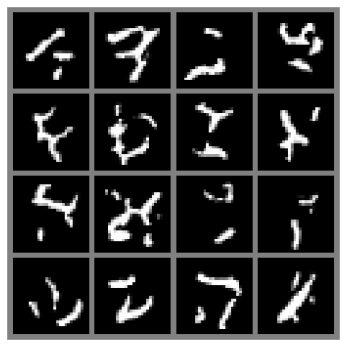

In [53]:
pl.seed_everything(44)
samples = flow_dict["vardeq"]["model"].sample(img_shape=[16,1,28,28])
show_imgs(samples.cpu())

INFO:lightning_fabric.utilities.seed:Seed set to 42


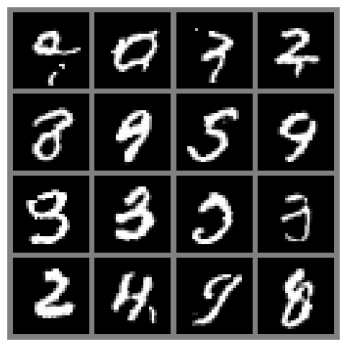

In [54]:
pl.seed_everything(42)
samples = flow_dict["multiscale"]["model"].sample(img_shape=[16,8,7,7])
show_imgs(samples.cpu())

По нескольким образцам можно увидеть четкую разницу между простой и многослойной моделью. Однослойная модель узнала только локальные, небольшие корреляции, в то время как многослойная модель смогла узнать полные, глобальные отношения, которые формируют цифры. Это демонстрирует еще одно преимущество многослойной модели. В отличие от VAE, выходные данные четкие, поскольку нормализационные потоки могут естественным образом моделировать сложные, многомодальные распределения, в то время как VAE имеют независимый выходной шум декодера. Тем не менее, образцы из этого потока далеки от совершенства, поскольку не все образцы показывают истинные цифры.

### **Интерполяция в скрытом пространстве**

Другой популярный тест на гладкость скрытого пространства генеративных моделей — интерполяция между двумя обучающими примерами. Поскольку нормализационные потоки строго обратимы, можно гарантировать, что любое изображение представлено в скрытом пространстве. Снова сравним модель вариационного деквантования с многослойной моделью ниже.

In [55]:
@torch.no_grad()
def interpolate(model, img1, img2, num_steps=8):
    """
    Входные данные:
        model - объект класса ImageFlow, представляющий (обученную) модель потока
        img1, img2 - Тензоры изображения формы [1, 28, 28]. Изображения между которыми следует интерполировать.
        num_steps - Количество шагов интерполяции. 8 шагов интерполяции означают 6 промежуточных изображений помимо img1 и img2.
    """
    imgs = torch.stack([img1, img2], dim=0).to(model.device)
    z, _ = model.encode(imgs)
    alpha = torch.linspace(0, 1, steps=num_steps, device=z.device).view(-1, 1, 1, 1)
    interpolations = z[0:1] * alpha + z[1:2] * (1 - alpha)
    interp_imgs = model.sample(interpolations.shape[:1] + imgs.shape[1:], z_init=interpolations)
    show_imgs(interp_imgs, row_size=8)

exmp_imgs, _ = next(iter(train_loader))

INFO:lightning_fabric.utilities.seed:Seed set to 42


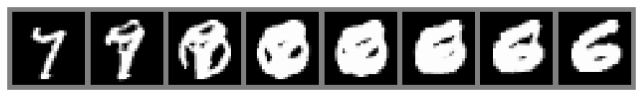

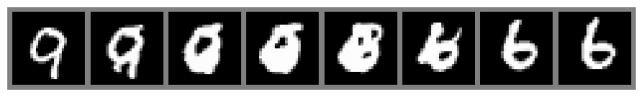

In [56]:
pl.seed_everything(42)
for i in range(2):
    interpolate(flow_dict["vardeq"]["model"], exmp_imgs[2*i], exmp_imgs[2*i+1])

INFO:lightning_fabric.utilities.seed:Seed set to 42


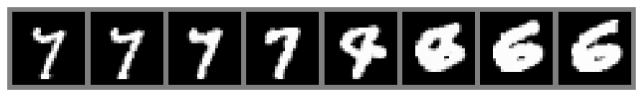

In [ ]:
pl.seed_everything(42)
for i in range(2):
    interpolate(flow_dict["multiscale"]["model"], exmp_imgs[2*i], exmp_imgs[2*i+1])

Интерполяции многослойной модели приводят к более реалистичным цифрам (первая строка $7\leftrightarrow 8\leftrightarrow 6$, вторая строка $9\leftrightarrow 6$), в то время как вариационная модель деквантования фокусируется на локальных паттернах, которые глобально не образуют цифру. Для многослойной модели мы фактически не делали «истинную» интерполяцию между двумя изображениями, поскольку не рассматривали переменные, которые были разделены вдоль потока (они были выбраны случайным образом для всех образцов). Однако, как будет видно в следующем эксперименте, ранние переменные не оказывают большого влияния на общее изображение.

### **Визуализация скрытых значений на разных уровнях многослойности**

Далее сосредоточимся больше на многослойном потоке. Проанализируем, какая информация хранится в переменных, разделенных на ранних уровнях, и какая информация для конечных переменных. Для этого мы выбираем 8 изображений, каждое из которых разделяет те же конечные скрытые переменные, но отличается в другой части скрытых переменных. Ниже визуализируем три примера этого:

In [ ]:
pl.seed_everything(44)
for _ in range(3):
    z_init = flow_dict["multiscale"]["model"].prior.sample(sample_shape=[1,8,7,7])
    z_init = z_init.expand(8, -1, -1, -1)
    samples = flow_dict["multiscale"]["model"].sample(img_shape=z_init.shape, z_init=z_init)
    show_imgs(samples.cpu())

Заметно, что ранол разделенные переменные действительно оказывают меньшее влияние на изображение. Тем не менее, небольшие различия можно заметить, если внимательно посмотреть на границы цифр. Например, в середине верхняя часть 3 имеет разную толщину для разных образцов, хотя все они представляют одну и ту же грубую структуру. Это показывает, что поток действительно учится разделять информацию более высокого уровня в конечных переменных, в то время как рано разделенные переменные содержат локальные шумовые паттерны.

### **Визуализация деквантования**

В качестве заключительной части блокноте рассмотрим эффект вариационного деквантования. Мы мотивировали вариационное деквантование проблемой резких краев/границ, которые трудно моделировать, и поток скорее предпочтет гладкие, априорные распределения. Чтобы проверить, как потоки в модуле вариационного деквантования узнали распределение шума $q(u|x)$, мы можем построить гистограмму выходных значений из модуля деквантования и вариационного деквантования.

In [ ]:
def visualize_dequant_distribution(model : ImageFlow, imgs : torch.Tensor, title:str=None):
    """
    Входные данные:
        model - Поток, распределение деквантования которого мы хотим визуализировать
        imgs - Примеры обучающих изображений, на которых мы хотим визуализировать распределение деквантования
    """
    imgs = imgs.to(device)
    ldj = torch.zeros(imgs.shape[0], dtype=torch.float32).to(device)
    with torch.no_grad():
        dequant_vals = []
        for _ in tqdm(range(8), leave=False):
            d, _ = model.flows[0](imgs, ldj, reverse=False)
            dequant_vals.append(d)
        dequant_vals = torch.cat(dequant_vals, dim=0)
    dequant_vals = dequant_vals.view(-1).cpu().numpy()
    sns.set()
    plt.figure(figsize=(10,3))
    plt.hist(dequant_vals, bins=256, color=to_rgb("C0")+(0.5,), edgecolor="C0", density=True)
    if title is not None:
        plt.title(title)
    plt.show()
    plt.close()

sample_imgs, _ = next(iter(train_loader))

In [ ]:
visualize_dequant_distribution(flow_dict["simple"]["model"], sample_imgs, title="Деквантование")

In [ ]:
visualize_dequant_distribution(flow_dict["vardeq"]["model"], sample_imgs, title="Вариационное деквантование")

Распределение деквантования на первом графике показывает, что изображения MNIST имеют сильный уклон в сторону 0 (черный), и их распределение имеет резкую границу, как упоминалось ранее. Модель вариационного деквантования действительно узнала гораздо более гладкое распределение с гауссовой кривой, которую можно смоделировать гораздо лучше. Для других значений нам нужно будет визуализировать распределение $q(u|x)$ на более глубоком уровне, в зависимости от $x$. Однако, поскольку все $u$ взаимодействуют и зависят друг от друга, нам нужно будет визуализировать распределение в 784 измерениях, что уже не так интуитивно понятно.

## **Заключение**

Мы увидели, как реализовать собственный нормализационный поток, и какие трудности возникают, если мы хотим применить их к изображениям. Деквантование является важным шагом в отображении дискретных изображений в непрерывное пространстводля предотвращения нежелательных решений с дельта-пиками. В то время как деквантование создает гиперкубы с жесткой границей, вариационное деквантование позволяет нам гораздо лучше подогнать поток к данным. Это позволяет нам получить более низкую оценку бит на измерение, не влияя при этом на скорость выборки. Самый распространенный элемент потока, слой связи, прост в реализации и при этом эффективен. Кроме того, многомасштабные архитектуры помогают захватывать глобальный контекст изображения, позволяя нам эффективно масштабировать поток. Нормализующие потоки являются интересной альтернативой VAE, поскольку они позволяют получить точную оценку правдоподобия в непрерывном пространстве, и у нас есть гарантия того, что каждый возможный вход $x$ имеет соответствующий скрытый вектор $z$. Однако даже за пределами непрерывных входов и изображений потоки могут применяться и позволяют нам использовать структуру данных в скрытом пространстве, например, на графиках для задачи генерации молекул. В целом, нормализация потоков является захватывающей областью исследований, которая вероятно будет продолжаться в течение следующих лет.